In [ ]:
import os 
import time 
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy.special import j0
import plotly.graph_objects as go
from iminuit.cost import LeastSquares
from scipy.integrate import fixed_quad

In [ ]:
# experimental data
save_folder = 'run7'
n_points = 5000

lower_factor = 0.99
upper_factor = 2 - lower_factor

# Load experimental data
atlas_data = pd.read_csv('../../../../data/ens_atlas_difc0_2.dat', delim_whitespace=True, header=None)
totem_data = pd.read_csv('../../../../data/ens_totem_difc0_2.dat', delim_whitespace=True, header=None)

# Function to process data for each experiment
def process_data(data, energy_blocks):
    x_values = []
    y_values = []
    y_errors = []
    
    for start, end in energy_blocks:
        block = data.iloc[start:end] if end is not None else data.iloc[start:]
        x_values.append(block[0].values)
        y_values.append(block[1].values)
        y_errors.append(block[2].values)
    
    return x_values, y_values, y_errors

# Energy ranges for each experiment (7TeV, 8TeV, 13TeV)
atlas_blocks = [(0, 29), (29, 58), (58, None)]
totem_blocks = [(0, 65), (65, 118), (118, None)]

# Process data
x_atlas, y_atlas, yerr_atlas = process_data(atlas_data, atlas_blocks)

# Extract values by energy (index 0=7TeV, 1=8TeV, 2=13TeV)
x_7_atlas, y_7_atlas, yerr_7_atlas = x_atlas[0], y_atlas[0], yerr_atlas[0]
x_8_atlas, y_8_atlas, yerr_8_atlas = x_atlas[1], y_atlas[1], yerr_atlas[1]
x_13_atlas, y_13_atlas, yerr_13_atlas = x_atlas[2], y_atlas[2], yerr_atlas[2]

In [ ]:
# setting parameters
b_0 = (33 - 6) / (12 * np.pi)
Lambda = 0.284  # ΛQCD in GeV
gamma_1 = 0.084
gamma_2 = 2.36
rho = 4.0
s0 = 1.0
alpha_prime = 0.25



ensemble_parameters = {
    'atlas': {
        'log': {
            'epsilon': 0.0753,
            'mg': 0.356,
            'a1': 1.373,
            'a2': 2.50
        },
        'pl': {
            'epsilon': 0.0753,
            'mg': 0.421,
            'a1': 1.517,
            'a2': 2.05
        }
    },
    'totem': {
        'log': {
            'epsilon': 0.0892,
            'mg': 0.380,
            'a1': 1.491,
            'a2': 2.77
        },
        'pl':{
            'epsilon': 0.0892,
            'mg': 0.447,
            'a1': 1.689,
            'a2': 1.7
        }
    }
}

ensemble_atlas = 'atlas'  
ensemble_totem = 'totem'

log_model_type = 'log'
pl_model_type = 'pl'   

def get_parameters_with_variations(ensemble_parameters, ensemble_name, model_type, lower_factor=lower_factor, upper_factor=upper_factor):
    # Obtém os parâmetros iniciais
    initial_params = ensemble_parameters[ensemble_name][model_type]
    
    # Cria as variações
    initial_params_low = {k: v * lower_factor for k, v in initial_params.items()}
    initial_params_high = {k: v * upper_factor for k, v in initial_params.items()}
    
    return initial_params, initial_params_low, initial_params_high

# Get parameters for selected configuration
initial_params_pl_atlas = ensemble_parameters[ensemble_atlas][pl_model_type]

# Para Atlas
initial_params_pl_atlas, initial_params_low_pl_atlas, initial_params_high_pl_atlas = \
    get_parameters_with_variations(ensemble_parameters, ensemble_atlas, pl_model_type)




In [ ]:
# def model functions 
# --- Model functions, all using q2 notation --- 

def m2_log(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return mg ** 2 * ratio ** (-1 - gamma_1)


def m2_pl(q2, mg):
    lambda_squared = Lambda ** 2
    rho_mg_squared = rho * mg ** 2
    ratio = np.log((q2 + rho_mg_squared) / lambda_squared) / np.log(rho_mg_squared / lambda_squared)
    return (mg ** 4 / (q2 + mg ** 2)) * ratio ** (gamma_2 - 1)


def G_p(q2, a1, a2):
    return np.exp(-(a1 * q2 + a2 * q2 ** 2))


def alpha_D(q2, mg, m2_func):
    m2 = m2_func(q2, mg)
    return 1.0 / (b_0 * (q2 + m2) * np.log((q2 + 4 * m2) / (Lambda ** 2)))


# --- Amplitudes T1 and T2 rewritten with strict q2 notation ---

def T_1(k, q2, phi, mg, a1, a2, m2_func):
    q  = np.sqrt((q2))     # this is |q|
    k2 = k ** 2

    qk_cos = q * (k) * np.cos(phi)

    qk_plus_squared  = q2/4 + qk_cos + k2
    qk_minus_squared = q2/4 - qk_cos + k2

    alpha_D_plus  = alpha_D(qk_plus_squared,  mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)

    G0 = G_p(q2, a1, a2)

    return alpha_D_plus * alpha_D_minus * (G0 ** 2)


def T_2(k, q2, phi, mg, a1, a2, m2_func):
    q  = np.sqrt((q2))
    k2 = k ** 2

    qk_cos = q * (k) * np.cos(phi)

    qk_plus_squared  = q2/4 + qk_cos + k2
    qk_minus_squared = q2/4 - qk_cos + k2

    alpha_D_plus  = alpha_D(qk_plus_squared,  mg, m2_func)
    alpha_D_minus = alpha_D(qk_minus_squared, mg, m2_func)

    factor = q2 + 9 * abs(k2 - q2/4)

    G0     = G_p(q2,    a1, a2)
    G_minus = G_p(factor, a1, a2)

    return alpha_D_plus * alpha_D_minus * G_minus * (2 * G0 - G_minus)

def sigma_tot(amp_value, s):
    return amp_value.imag / s * 0.389379323

def amp_calculation(diff_T, s, epsilon, t):
    alpha_pomeron = 1.0 + epsilon + alpha_prime * t
    regge_factor = (s**alpha_pomeron) * 1/(s0**(alpha_pomeron-1))
    return 1j * 8 * regge_factor * diff_T  

def differential_sigma(amp_value, s):
    amp_squared = amp_value * amp_value.conjugate()
    denominator = (16 * np.pi * s**2)
    return amp_squared / denominator * 0.389379323


In [ ]:
def full_int(mg, a1, a2, m2_func, q2_val, sqrt_s):
    q2_val = np.atleast_1d(q2_val)
    results = []

    for q2 in q2_val:                      # <- q2 is the correct variable
        def integrand(y, x, mg, a1, a2, m2_func, q2):
            k = sqrt_s * x
            phi = 2 * np.pi * y
            jacobian = 2 * np.pi * sqrt_s
            return k * (
                T_1(k, q2, phi, mg, a1, a2, m2_func)   # <-- FIXED: q instead of q_val
                - T_2(k, q2, phi, mg, a1, a2, m2_func)
            ) * jacobian

        def inner_integral(x):
            integral_real = fixed_quad(
                lambda y: np.real(integrand(y, x, mg, a1, a2, m2_func, q2)),
                0, 1, n=n_points
            )[0]
            integral_imag = fixed_quad(
                lambda y: np.imag(integrand(y, x, mg, a1, a2, m2_func, q2)),
                0, 1, n=n_points
            )[0]
            return integral_real + 1j * integral_imag

        integral_value = fixed_quad(inner_integral, 0, 1, n=n_points)[0]
        results.append(integral_value)

    return np.array(results) if len(results) > 1 else results[0]

In [ ]:
# Calculates and plot dif sigma 
diff_t_born = []
def get_dif_sigma(epsilon, mg, a1, a2, mg_model):

    sqrt_s = 7000
    scale = 1  # caso único
    start_q2 = 0.006
    max_q2   = 0.204
    q2_step  = 0.001

    lst_q2 = []
    lst_dif_sigma = []

    q2 = start_q2
    while q2 <= max_q2:
        t = -q2

        integral_value = full_int(mg, a1, a2, mg_model, q2, sqrt_s)


        diff_T = integral_value
        # print(diff_T)
        diff_t_born.append(diff_T)
        # print(f"q2: {q2}, diff_T: {diff_T}")

        s          = sqrt_s**2
        amp_value  = amp_calculation(diff_T, s, epsilon, t)
        # print(amp_value) 
        dif_sigma  = differential_sigma(amp_value, s) * scale
        # print(dif_sigma)

        lst_q2.append(q2)
        lst_dif_sigma.append(dif_sigma)

        q2 += q2_step
        # print(q2)

    return {sqrt_s: (lst_q2, lst_dif_sigma)}

#for pl atlas
dif_sigma_pl_atlas = get_dif_sigma(
    ensemble_parameters["atlas"]["pl"]['epsilon'],
    ensemble_parameters["atlas"]["pl"]['mg'], 
    ensemble_parameters["atlas"]["pl"]['a1'],
    ensemble_parameters["atlas"]["pl"]['a2'],
    m2_pl
)

dif_sigma_pl_atlas_7_q2 = dif_sigma_pl_atlas[7000][0]
dif_sigma_pl_atlas_7_values = dif_sigma_pl_atlas[7000][1]


def add_differential_trace(fig, x, y, label, color='red', mg_model= 'log', legend=True, size = 4, width = 2):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        line=dict(color=color, width=width),
        marker=dict(size=size),
        name=f'{label}, {mg_model}',
        showlegend=legend,

    ))

def add_data_trace(fig, x, y, y_error, scale=1.0, color='black', size=4,
                           name=None, show_label=True, mode='markers'):
    fig.add_trace(go.Scatter(
        x=x,
        y=y * scale,
        mode=mode,
        marker=dict(color=color, size=size),
        error_y=dict(
            type='data',
            array=y_error * scale,
            visible=True
        ),
        name=name if show_label else None,
        showlegend=show_label
    ))

fig_atlas = go.Figure()


# for pl atlas
add_differential_trace(fig_atlas, dif_sigma_pl_atlas_7_q2, np.real(dif_sigma_pl_atlas_7_values),label='7 TeV', color='blue', mg_model='pl')

#data points
add_data_trace(fig_atlas, x_7_atlas, y_7_atlas, yerr_7_atlas, name='ATLAS 7 TeV', show_label=True, mode='markers')

# Atualiza layout
fig_atlas.update_layout(
    title='dσ/dt vs. |t| - Log and PL models in ATLAS',
    xaxis_title='|t| (GeV²)',
    yaxis_title='dσ/dt (mb/GeV²)',
    yaxis_type='log',
    legend_title='Mass Model',
    plot_bgcolor='white',
    hovermode='x unified'
)

fig_atlas.update_xaxes(gridcolor='lightgray')
fig_atlas.update_yaxes(gridcolor='lightgray')

# fig_atlas.show(renderer='browser')


In [ ]:
# # PLOT BORN SIGMA TOT =============================================================
# # 
# # =============================================================


data_sigma_tot_atlas = pd.read_csv(
    "../../../../data/sigma_tot_2/ensemble_StRh_atlas.dat",
    delim_whitespace=True,
    header=None,
    nrows=70
)

x_sigma_tot_atlas = data_sigma_tot_atlas[0].to_numpy()
y_sigma_tot_atlas = data_sigma_tot_atlas[1].to_numpy()
y_error_sigma_tot_atlas = data_sigma_tot_atlas[2].to_numpy()

lst_born_amp = []

start_sqrt_s = 1
max_sqrt_s = 13010
step = 100

def add_total_trace(fig, x, y, color='red', label='', line_style='solid', legend=True, size = 3, width = 2):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        line=dict(color=color, width=width, dash=line_style),
        marker=dict(size=size),
        name = label, 
        showlegend=legend
    ))

def get_sigma_tot(epsilon, mg, a1, a2, mg_model):

    lst_sigma_tot = []
    lst_sqrt_s = []

    sqrt_s = start_sqrt_s

    while sqrt_s <= max_sqrt_s:

        s = sqrt_s ** 2

        integral_value = full_int(mg, a1, a2, mg_model, 0.0, sqrt_s) 

        born_amp = amp_calculation(integral_value, s, epsilon, 0)
        # print(born_amp)
        lst_born_amp.append(born_amp)
        
        lst_sigma_tot.append(sigma_tot(
            amp_calculation(integral_value, s, epsilon, 0), s))
        
        lst_sqrt_s.append(sqrt_s)
        sqrt_s += step
    return lst_sigma_tot, lst_sqrt_s

##-----------------------------------------------------------------------------------------------

sigma_tot_pl_atlas = get_sigma_tot(
    ensemble_parameters["atlas"]["pl"]['epsilon'],
    ensemble_parameters["atlas"]["pl"]['mg'], 
    ensemble_parameters["atlas"]["pl"]['a1'],
    ensemble_parameters["atlas"]["pl"]['a2'],
    m2_pl
)

sigma_tot_pl_atlas_values = sigma_tot_pl_atlas[0]
lst_sqrt_s = sigma_tot_pl_atlas[1]



fig = go.Figure()

add_total_trace(fig, lst_sqrt_s, sigma_tot_pl_atlas_values, color='blue', label='PL Atlas', line_style='solid')

#-----------------------------------------------------------------------------------------------
#----

add_data_trace(fig, x_sigma_tot_atlas, y_sigma_tot_atlas, y_error_sigma_tot_atlas, name='ATLAS', show_label=True, mode='markers')

fig.update_layout(
    title = 'σ_tot vs. √s - Ensemble Atlas and Totem in Log and PL model',
    xaxis=dict(
        title='√s [GeV]',
        type='log',
        range=[np.log10(2000), np.log10(14000)],
    ),
    yaxis=dict(
        title='σ_tot [mb]',
        range=[80, 125]
    ),
    showlegend=True,
    legend=dict(
        title='Ensembles'
    ),
    plot_bgcolor='white',
    hovermode='x unified'
)
    
fig.update_xaxes(gridcolor='lightgray')
fig.update_yaxes(gridcolor='lightgray')

# fig.show(renderer="browser")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import fixed_quad
from scipy.special import j0
n_points = 1000

# Model parameters (adjust these based on your fit)
mg = ensemble_parameters["atlas"]["pl"]["mg"]
a1 = ensemble_parameters["atlas"]["pl"]["a1"]
a2 = ensemble_parameters["atlas"]["pl"]["a2"]  # GeV^-4

def chi_b(sqrt_s, b_values, mg, a1, a2):
    """
    Calculate eikonal function χ(s,b) for given b values
    """
    s = sqrt_s ** 2
    
    # Define q range for integration (q = sqrt(-t))
    q_max = 1 # GeV
    n_q = 500
    
    chi_values = []
    
    for b in b_values:
        print(b)
        def integrand(q):
            q2 = q ** 2
            t = -q2

            diff_t = full_int(mg, a1, a2, m2_pl, q2, sqrt_s)[0]
            amp_full = amp_calculation(diff_t, s, ensemble_parameters["atlas"]["pl"]["epsilon"], t)
            
            return q * j0(b * q) * amp_full
        
        # Integrate over q
        integral_real = fixed_quad(lambda q: np.real(integrand(q)), 0, q_max, n=n_points)[0]
        integral_imag = fixed_quad(lambda q: np.imag(integrand(q)), 0, q_max, n=n_points)[0]
        
        chi_value = (integral_real + 1j * integral_imag) / s
        chi_values.append(chi_value)
        
    
    return np.array(chi_values)

# Calculate χ(b) for √s = 7000 GeV
sqrt_s = 7000  # GeV
b_values = np.linspace(0, 10, 50)  # fm (impact parameter)

print("Calculating χ(b) for √s = 7000 GeV...")
chi_values = chi_b(sqrt_s, b_values, mg, a1, a2)

plt.plot(b_values, np.imag(chi_values), 'r-', linewidth=2, label='Imaginary part')
plt.xlabel('b (fm)')
plt.ylabel('Im[χ(b)]')
plt.title('Imaginary part of eikonal function')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


Calculating amp_eik for sqrt(s) = 10000.0 GeV...
  b = 0.20
  b = 0.60
  b = 1.00
  b = 1.40
  b = 1.80
  b = 2.20
  b = 2.60
  b = 3.00
  b = 3.40
  b = 3.80
  b = 4.20
  b = 4.60
  b = 5.00
  b = 5.40
  b = 5.80
  b = 6.20
  b = 6.60
  b = 7.00
  b = 7.40
  b = 7.80
  b = 8.20
  b = 8.60
  b = 9.00
  b = 9.40
  b = 9.80
  b = 10.20
  b = 10.60
  b = 11.00
  b = 11.40
  b = 11.80
  b = 12.20
  b = 12.60
  b = 13.00
  b = 13.40
  b = 13.80
  b = 14.20
  b = 14.60
  b = 15.00
  b = 15.40
  b = 15.80
  b = 16.20
  b = 16.60
  b = 17.00
  b = 17.40
  b = 17.80
  b = 18.20
  b = 18.60
  b = 19.00
  b = 19.40
  b = 19.80
  amp_eik = 3.594100e+01+0.000000e+00j

Calculating amp_eik for sqrt(s) = 13000.0 GeV...
  b = 0.20
  b = 0.60
  b = 1.00
  b = 1.40
  b = 1.80
  b = 2.20
  b = 2.60
  b = 3.00
  b = 3.40
  b = 3.80
  b = 4.20
  b = 4.60
  b = 5.00
  b = 5.40
  b = 5.80
  b = 6.20
  b = 6.60
  b = 7.00
  b = 7.40
  b = 7.80
  b = 8.20
  b = 8.60
  b = 9.00
  b = 9.40
  b = 9.80
  b = 10.20

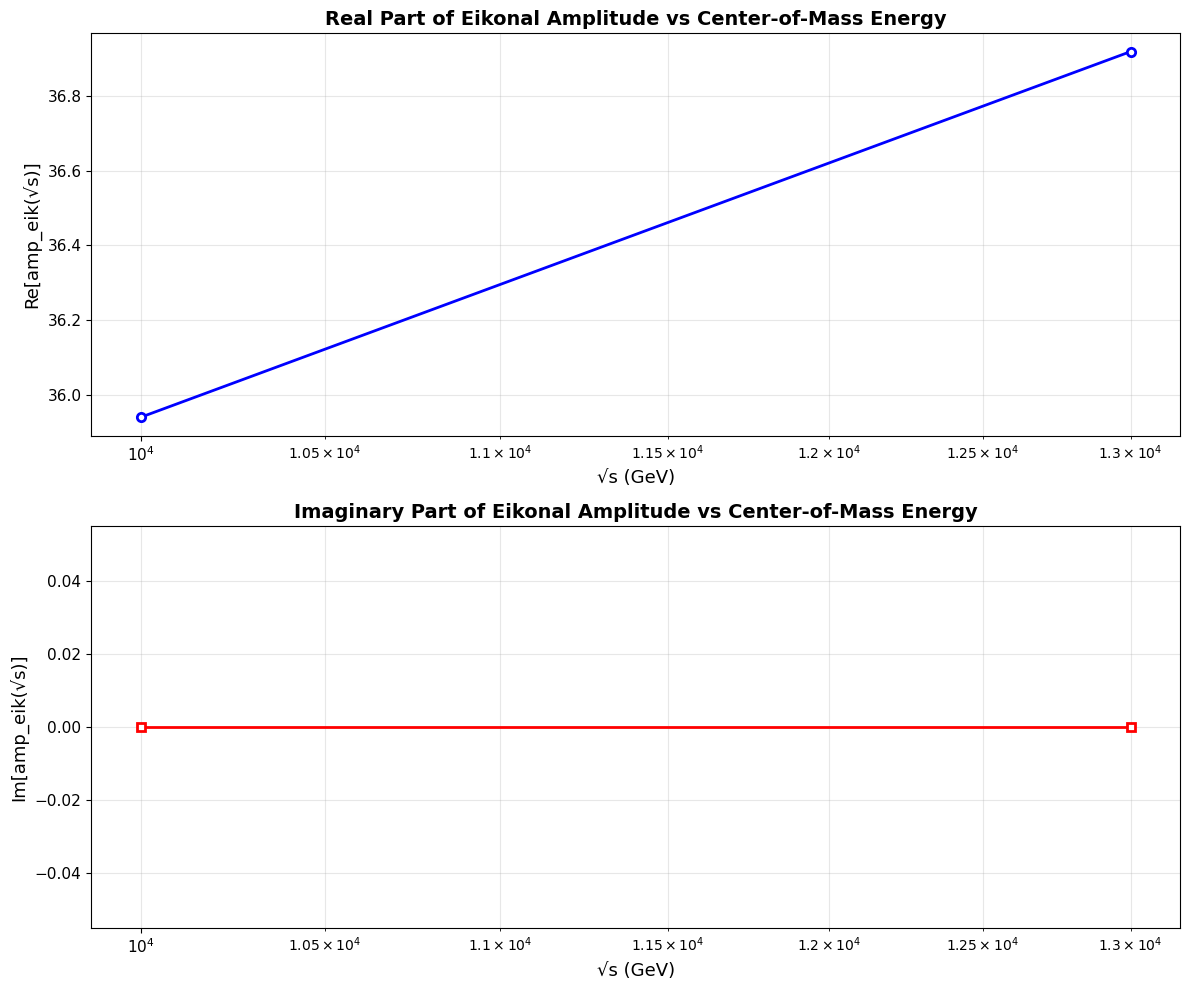

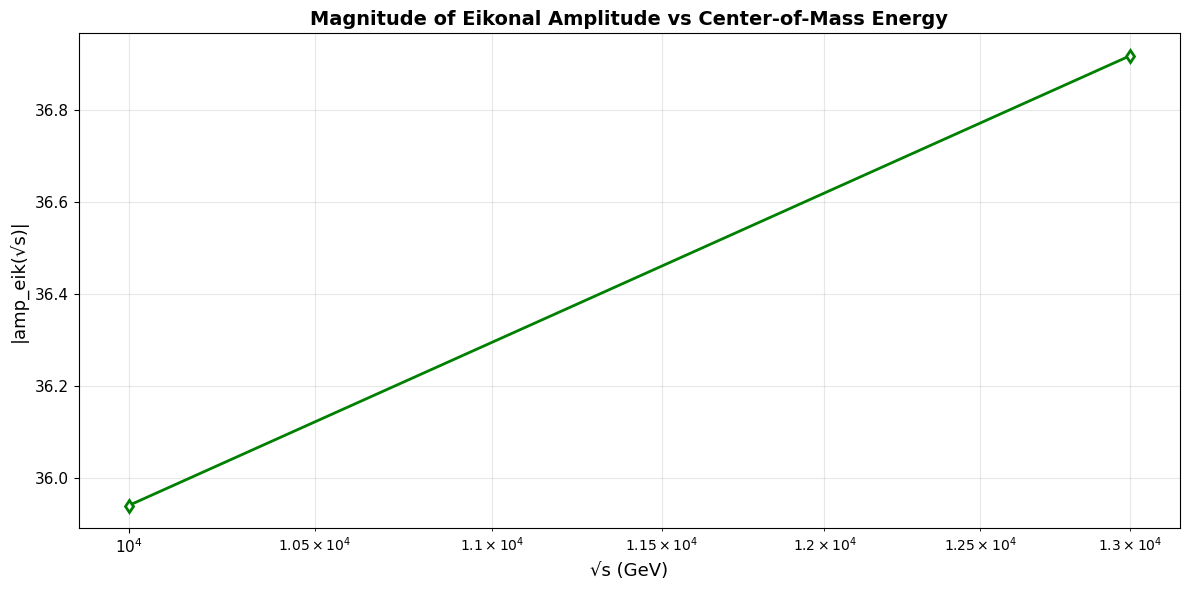


CALCULATION COMPLETE
Energy range: 10000.0 - 13000.0 GeV
Number of energy points: 2
amp_eik range (real): [3.594e+01, 3.692e+01]
amp_eik range (imag): [0.000e+00, 0.000e+00]


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import fixed_quad
from scipy.special import j0

n_points = 1000

# Model parameters (adjust these based on your fit)
mg = ensemble_parameters["atlas"]["pl"]["mg"]
a1 = ensemble_parameters["atlas"]["pl"]["a1"]
a2 = ensemble_parameters["atlas"]["pl"]["a2"]  # GeV^-4

def chi_b(sqrt_s, b_values, mg, a1, a2):
    """
    Calculate eikonal function χ(s,b) for given b values
    """
    s = sqrt_s ** 2
    
    # Define q range for integration (q = sqrt(-t))
    q_max = 30 # GeV
    n_q = 500
    
    chi_values = []
    
    for b in b_values:
        print(f"  b = {b:.2f}")
        def integrand(q):
            q2 = q ** 2
            t = -q2
            
            diff_t = full_int(mg, a1, a2, m2_pl, q2, sqrt_s)[0]
            amp_full = amp_calculation(diff_t, s, ensemble_parameters["atlas"]["pl"]["epsilon"], t)
            
            return q * j0(b * q) * amp_full
        
        # Integrate over q
        integral_real = fixed_quad(lambda q: np.real(integrand(q)), 0, q_max, n=n_points)[0]
        integral_imag = fixed_quad(lambda q: np.imag(integrand(q)), 0, q_max, n=n_points)[0]
        
        chi_value = (integral_real + 1j * integral_imag) / s
        chi_values.append(chi_value)
    
    return np.array(chi_values)


def calculate_amp_eik(sqrt_s, mg, a1, a2, b_max=20, n_b=100):
    """
    Calculate eikonal amplitude using Equation 24:
    amp_eik(sqrt(s)) = integral_0^b_max [b * db * (1 - exp(i*chi(b)))]
    
    Using midpoint Riemann sum for integration over b
    Since q = 0, j0(0) = 1
    """
    print(f"\nCalculating amp_eik for sqrt(s) = {sqrt_s} GeV...")
    
    # Create b values for integration (midpoints)
    db = b_max / n_b
    b_edges = np.linspace(0, b_max, n_b + 1)
    b_midpoints = (b_edges[:-1] + b_edges[1:]) / 2
    
    # Calculate chi(b) at midpoints
    chi_values = chi_b(sqrt_s, b_midpoints, mg, a1, a2)
    
    # Calculate integrand: b * (1 - exp(i*chi(b)))
    integrand = b_midpoints * (1 - np.exp(1j * chi_values))
    
    # Midpoint Riemann sum
    amp_eik = np.sum(integrand) * db
    
    return amp_eik


# ============================================================================
# PART 1: Calculate χ(b) for single √s = 7000 GeV (existing functionality)
# ============================================================================

# ============================================================================
# PART 2: Calculate and plot amp_eik(sqrt(s)) for range of energies
# ============================================================================

# Energy range: 500 to 13000 GeV
sqrt_s_values = np.linspace(10000, 13000, 2)  # 30 points for reasonable computation time

# Storage for results
amp_eik_values = []

# Calculate amp_eik for each sqrt(s)
for sqrt_s in sqrt_s_values:
    amp_eik = calculate_amp_eik(sqrt_s, mg, a1, a2, b_max=20, n_b=50)
    amp_eik_values.append(amp_eik)
    print(f"  amp_eik = {amp_eik:.6e}")

amp_eik_values = np.array(amp_eik_values)

# ============================================================================
# PLOTTING amp_eik(sqrt(s))
# ============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Real part
ax1.semilogx(sqrt_s_values, np.real(amp_eik_values), 'b-o', linewidth=2, 
             markersize=6, markerfacecolor='white', markeredgewidth=2)
ax1.set_xlabel('√s (GeV)', fontsize=13)
ax1.set_ylabel('Re[amp_eik(√s)]', fontsize=13)
ax1.set_title('Real Part of Eikonal Amplitude vs Center-of-Mass Energy', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')
ax1.tick_params(labelsize=11)

# Plot 2: Imaginary part
ax2.semilogx(sqrt_s_values, np.imag(amp_eik_values), 'r-s', linewidth=2, 
             markersize=6, markerfacecolor='white', markeredgewidth=2)
ax2.set_xlabel('√s (GeV)', fontsize=13)
ax2.set_ylabel('Im[amp_eik(√s)]', fontsize=13)
ax2.set_title('Imaginary Part of Eikonal Amplitude vs Center-of-Mass Energy', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# Optional: Plot magnitude
plt.figure(figsize=(12, 6))
plt.semilogx(sqrt_s_values, np.abs(amp_eik_values), 'g-d', linewidth=2, 
             markersize=6, markerfacecolor='white', markeredgewidth=2)
plt.xlabel('√s (GeV)', fontsize=13)
plt.ylabel('|amp_eik(√s)|', fontsize=13)
plt.title('Magnitude of Eikonal Amplitude vs Center-of-Mass Energy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CALCULATION COMPLETE")
print("="*60)
print(f"Energy range: {sqrt_s_values[0]:.1f} - {sqrt_s_values[-1]:.1f} GeV")
print(f"Number of energy points: {len(sqrt_s_values)}")
print(f"amp_eik range (real): [{np.real(amp_eik_values).min():.3e}, {np.real(amp_eik_values).max():.3e}]")
print(f"amp_eik range (imag): [{np.imag(amp_eik_values).min():.3e}, {np.imag(amp_eik_values).max():.3e}]")
print("="*60)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.integrate import fixed_quad
# from scipy.special import j0
# n_points = 500

# # Model parameters (adjust these based on your fit)
# mg = ensemble_parameters["atlas"]["pl"]["mg"]
# a1 = ensemble_parameters["atlas"]["pl"]["a1"]
# a2 = ensemble_parameters["atlas"]["pl"]["a2"]  # GeV^-4

# def chi_b(sqrt_s, b_values, mg, a1, a2):
#     """
#     Calculate eikonal function χ(s,b) for given b values
#     """
#     s = sqrt_s ** 2
    
#     # Define q range for integration (q = sqrt(-t))
#     q_max = 5.0  # GeV
#     n_q = 500
#     q_values = np.linspace(0, q_max, n_q)
    
#     chi_values = []
    
#     for b in b_values:
#         print(b)
#         def integrand(q):
#             q2 = q ** 2
#             t = -q2
            
#             # Calculate Born amplitude using your full_int function
#             amp_born = full_int(mg, a1, a2, m2_pl, q2, sqrt_s)[0]
            
#             # Apply Regge factor (from your amp_calculation function)
#             alpha_pomeron = 1.0 + ensemble_parameters["atlas"]["pl"]["epsilon"] + alpha_prime * t
#             regge_factor = (s ** alpha_pomeron) / (s0 ** (alpha_pomeron - 1))
#             amp_full = 1j * 8 * regge_factor * amp_born
            
#             return q * j0(b * q) * amp_full
        
#         # Integrate over q
#         integral_real = fixed_quad(lambda q: np.real(integrand(q)), 0, q_max, n=n_points)[0]
#         integral_imag = fixed_quad(lambda q: np.imag(integrand(q)), 0, q_max, n=n_points)[0]
        
#         chi_value = (integral_real + 1j * integral_imag) / s
#         chi_values.append(chi_value)
        
    
#     return np.array(chi_values)

# # Calculate χ(b) for √s = 7000 GeV
# sqrt_s = 7000  # GeV
# b_values = np.linspace(0, 20, 50)  # fm (impact parameter)

# print("Calculating χ(b) for √s = 7000 GeV...")
# chi_values = chi_b(sqrt_s, b_values, mg, a1, a2)

# # Plot the results
# plt.figure(figsize=(10, 6))

# plt.subplot(2, 2, 2)
# plt.plot(b_values, np.imag(chi_values), 'r-', linewidth=2, label='Imaginary part')
# plt.xlabel('b (fm)')
# plt.ylabel('Im[χ(b)]')
# plt.title('Imaginary part of eikonal function')
# plt.grid(True, alpha=0.3)
# plt.legend()

# plt.tight_layout()
# plt.show()


# # def calculate_amp_eik(sqrt_s, mg, a1, a2, b_max=10, n_b=100):
# #     """
# #     Calculate eikonal amplitude A_eik(s,t=0) using Equation 24
# #     At forward scattering (q=0), J₀(0)=1, so:
# #     A_eik(s,0) = is ∫₀^∞ b db [1 - exp(iχ(s,b))]
# #     """
# #     s = sqrt_s ** 2
    
# #     # Create b values for integration
# #     b_values = np.linspace(0, b_max, n_b)
    
# #     # Calculate χ(b) for all b values
# #     print(f"Calculating χ(b) for √s = {sqrt_s} GeV...")
# #     chi_values = chi_b(sqrt_s, b_values, mg, a1, a2)
    
# #     # Calculate integrand: b * [1 - exp(iχ(b))]
# #     # Note: J₀(0) = 1 for forward scattering
# #     integrand = b_values * (1 - np.exp(1j * chi_values))
    
# #     # Numerical integration using trapezoidal rule
# #     amp_eik = 1j * s * np.trapz(integrand, b_values)
    
# #     return amp_eik

# # # Calculate χ(b) for √s = 7000 GeV
# # sqrt_s_single = 7000  # GeV
# # b_values = np.linspace(0, 10, 50)  # fm (impact parameter)

# # print("Calculating χ(b) for √s = 7000 GeV...")
# # chi_values = chi_b(sqrt_s_single, b_values, mg, a1, a2)

# # # Calculate A_eik(√s) for a range of energies
# # sqrt_s_values = np.logspace(np.log10(500), np.log10(13000), 10)  # 500 GeV to 13 TeV
# # amp_eik_values = []

# # print("\nCalculating A_eik for different energies...")
# # for sqrt_s in sqrt_s_values:
# #     amp_eik = calculate_amp_eik(sqrt_s, mg, a1, a2, b_max=10, n_b=100)
# #     amp_eik_values.append(amp_eik)
# #     print(f"√s = {sqrt_s:.0f} GeV: A_eik = {amp_eik:.4e}")

# # amp_eik_values = np.array(amp_eik_values)

# # # Plot the results
# # fig = plt.figure(figsize=(14, 10))

# # # Plot χ(b) for single energy
# # plt.subplot(2, 2, 1)
# # plt.plot(b_values, np.real(chi_values), 'b-', linewidth=2, label='Real part')
# # plt.xlabel('b (fm)', fontsize=12)
# # plt.ylabel('Re[χ(b)]', fontsize=12)
# # plt.title(f'Real part of eikonal function at √s = {sqrt_s_single} GeV', fontsize=13)
# # plt.grid(True, alpha=0.3)
# # plt.legend()

# # plt.subplot(2, 2, 2)
# # plt.plot(b_values, np.imag(chi_values), 'r-', linewidth=2, label='Imaginary part')
# # plt.xlabel('b (fm)', fontsize=12)
# # plt.ylabel('Im[χ(b)]', fontsize=12)
# # plt.title(f'Imaginary part of eikonal function at √s = {sqrt_s_single} GeV', fontsize=13)
# # plt.grid(True, alpha=0.3)
# # plt.legend()

# # # Plot A_eik(√s) - Imaginary part
# # plt.subplot(2, 2, 4)
# # plt.semilogx(sqrt_s_values, np.imag(amp_eik_values), 'r-o', linewidth=2, markersize=4)
# # plt.xlabel('√s (GeV)', fontsize=12)
# # plt.ylabel('Im[A_eik(√s)]', fontsize=12)
# # plt.title('Imaginary Part of Eikonal Amplitude vs Center-of-Mass Energy', fontsize=13)
# # plt.grid(True, alpha=0.3, which='both')

# # plt.tight_layout()
# # plt.show()
